# LFP visualization

## Imports

In [1]:
import numpy as np
import quantities as pq
from neo.io import NixIO
import elephant
import matplotlib.pyplot as plt

## Functions

In [2]:
def compute_spike_triggered_average(spike_times, signal, max_lag):
    len_max_lag = int((max_lag.rescale('s') * signal.sampling_rate.rescale('Hz')).magnitude)
    
    times = signal.times
    len_times = len(times)
    ind_arr = []
    for i, spike_time in enumerate(spike_times):
        spike_time_ind = np.argmin(np.abs(times - spike_time))
        ind_start = spike_time_ind - len_max_lag
        ind_stop = spike_time_ind + len_max_lag
        if ind_start < 0 or ind_stop >= len_times:
            continue
        ind_arr.append(np.arange(ind_start, ind_stop, dtype=int))
    ind_arr = np.array(ind_arr)

    sta = signal.rescale('mV').magnitude.flatten()[ind_arr].mean(axis=0)
    lags = np.linspace(-max_lag, max_lag, len(sta), endpoint=False)

    return sta, lags


def compute_phase_locking_value(spike_times, signal, center_freq, return_phase_values=False):
    signal_wavelet = elephant.signal_processing.wavelet_transform(signal, frequency=[center_freq])
    phases = np.angle(signal_wavelet).squeeze()

    times = signal.times
    spike_time_inds = []
    for i, spike_time in enumerate(spike_times):
        spike_time_inds.append(np.argmin(np.abs(times - spike_time)))
    spike_time_inds = np.array(spike_time_inds)

    spike_time_phases = phases[spike_time_inds]
    spike_time_phase_vecs = np.exp(1.j * spike_time_phases)
    mean_vec = np.mean(spike_time_phase_vecs)
    plv = np.abs(mean_vec)

    if return_phase_values:    
        return plv, spike_time_phases
    else:
        return plv

## Load data

In [3]:
data_dir = "../../Data"
with NixIO(f"{data_dir}/rat_retreat_meta_1kHz.nix", mode="ro") as io:
    block = io.read_block()
seg = block.segments[0]
signals = seg.analogsignals[0]
spiketrains = seg.spiketrains

Focus on the first unit and its channel

In [4]:
spiketrain = spiketrains[0]
channel_index = int(spiketrain.annotations['channel'].split('_')[1])
signal = signals[:, channel_index]

spiketrain

SpikeTrain containing 8963 spikes; units s; datatype float64 
name: 'cluster_32_Ch_25'
annotations: {'nix_name': 'neo.spiketrain.c76d122c03444f34b75d78948704b9e1',
  'spike_id': np.int64(32),
  'channel': 'Ch_25',
  'unit_type': 'single_unit'}
time: 0.0 s to 704.9999666666666 s

Plot the spike train and the LFP together

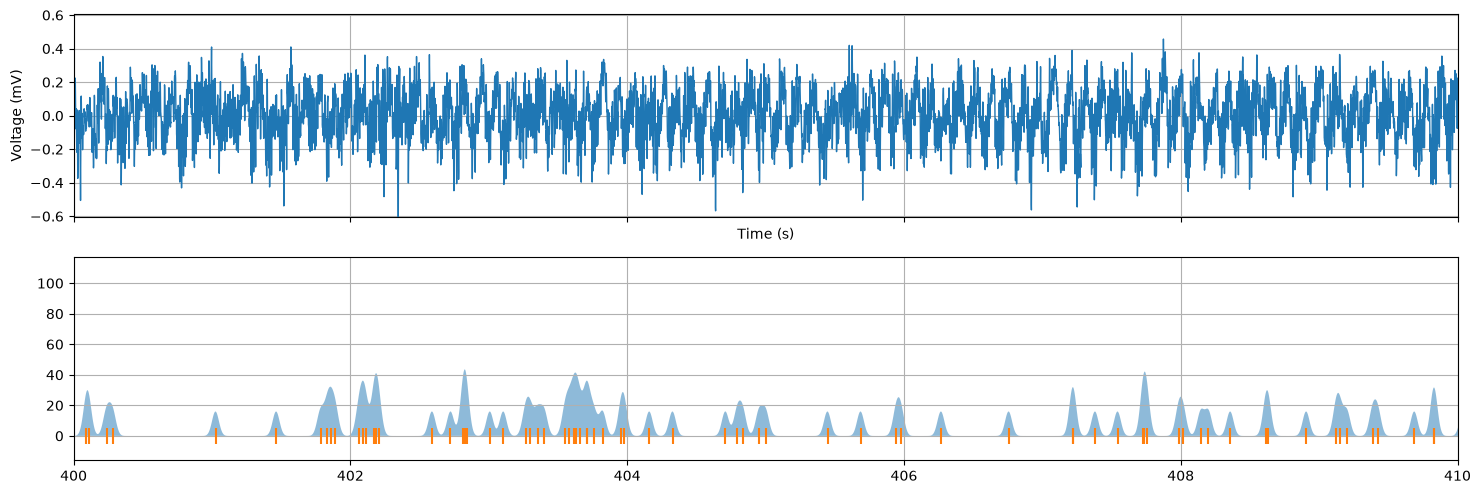

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

ax = axes[0]
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (mV)")
xs = signal.times.rescale('s').magnitude
ys = signal.rescale('mV').magnitude.flatten()
ax.plot(xs, ys, lw=1)

amp_med = np.median(ys)
ax.set_ylim(-50*amp_med, 50*amp_med)
ax.grid()

ax = axes[1]
kernel = elephant.kernels.GaussianKernel(sigma=25*pq.ms)
inst_rate = elephant.statistics.instantaneous_rate(spiketrain, sampling_period=1*pq.ms, kernel=kernel)
ax.fill_between(inst_rate.times, inst_rate.magnitude.flatten(), np.zeros_like(inst_rate.times), alpha=0.5)
times = spiketrain.rescale('s').magnitude
ax.eventplot(times, linelengths=10, lineoffsets=0, color='C1')

ax.set_xlim(400, 410)
ax.grid()

fig.tight_layout()
plt.show()

## Compute spike triggered average LFP

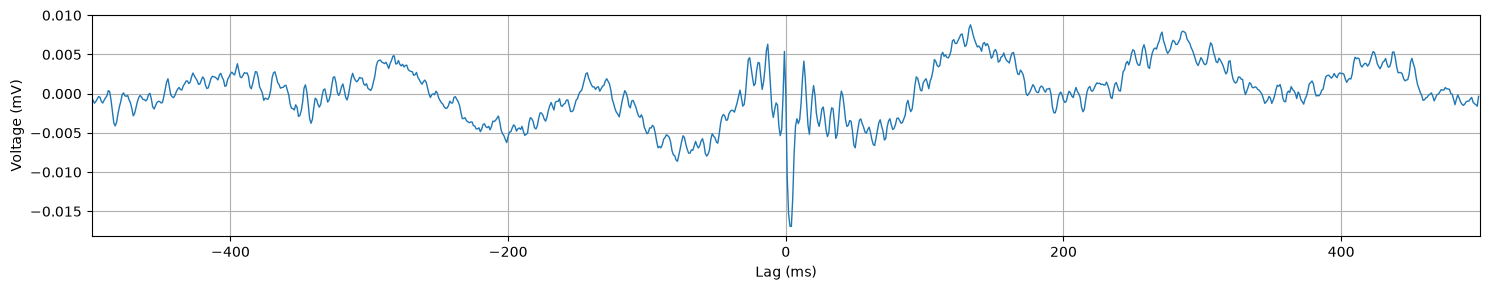

In [6]:
max_lag = 500 * pq.ms

spike_times = spiketrain.times
sta, lags = compute_spike_triggered_average(spike_times, signal, max_lag)

fig, ax = plt.subplots(figsize=(15, 3))
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Voltage (mV)")
ax.plot(lags, sta, lw=1)
ax.set_xlim(-max_lag, max_lag)
ax.grid()
fig.tight_layout()
plt.show()

Compute the STA separately for before and after the ketamine injection

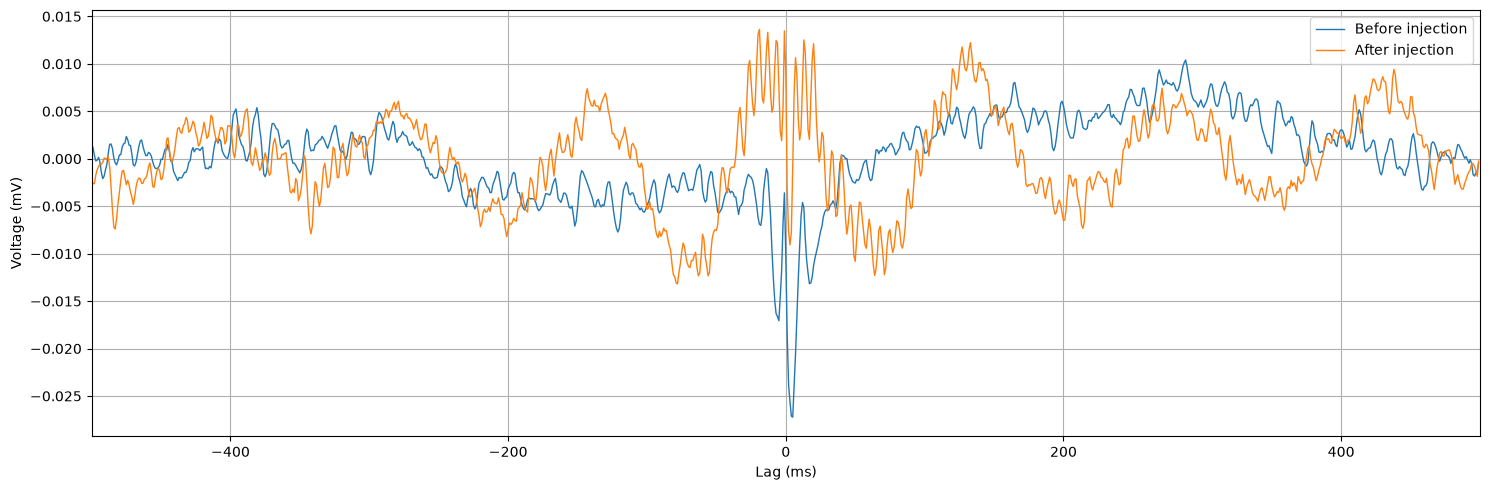

In [7]:
max_lag = 500 * pq.ms

spike_times = spiketrain.times
spike_times_pre = spike_times[spike_times < 372 * pq.s]
sta_pre, lags = compute_spike_triggered_average(spike_times_pre, signal, max_lag)
spike_times_post = spike_times[spike_times >= 372 * pq.s]
sta_post, lags = compute_spike_triggered_average(spike_times_post, signal, max_lag)

fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Voltage (mV)")
ax.plot(lags, sta_pre, lw=1, label="Before injection")
ax.plot(lags, sta_post, lw=1, label="After injection")
ax.set_xlim(-max_lag, max_lag)
ax.grid()
ax.legend()
fig.tight_layout()
plt.show()

Check the frequency components of the STAs, and compare them to those of LFP.

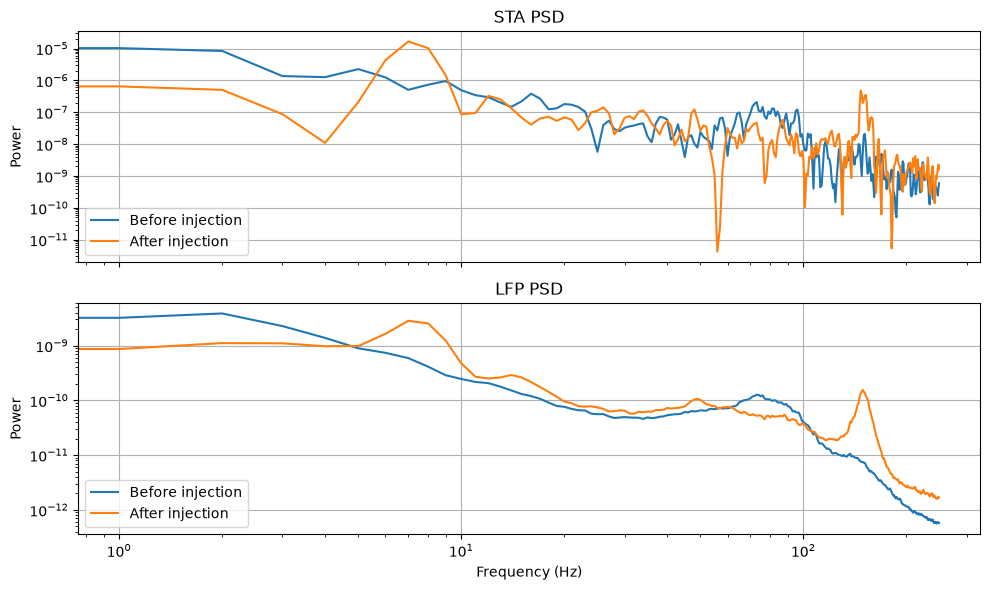

In [8]:
freqs_sta, psd_sta_pre = elephant.spectral.welch_psd(sta_pre, fs=signal.sampling_rate, frequency_resolution=1*pq.Hz)
_, psd_sta_post = elephant.spectral.welch_psd(sta_post, fs=signal.sampling_rate, frequency_resolution=1*pq.Hz)

signal_pre = signal.time_slice(t_start=0*pq.s, t_stop=372*pq.s)
freqs_lfp_pre, psd_lfp_pre = elephant.spectral.welch_psd(signal_pre, frequency_resolution=1*pq.Hz)
signal_post = signal.time_slice(t_start=372*pq.s, t_stop=None)
freqs_lfp_post, psd_lfp_post = elephant.spectral.welch_psd(signal_post, frequency_resolution=1*pq.Hz)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

ax = axes[0]
ax.set_title("STA PSD")
ax.set_ylabel("Power")
mask = freqs_sta < 250 * pq.Hz
ax.plot(freqs_sta[mask], psd_sta_pre[mask], label="Before injection")
ax.plot(freqs_sta[mask], psd_sta_post[mask], label="After injection")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()
ax.legend(loc='lower left')

ax = axes[1]
ax.set_title("LFP PSD")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
mask = freqs_lfp_pre < 250 * pq.Hz
ax.plot(freqs_lfp_pre[mask], psd_lfp_pre.flatten()[mask], label="Before injection")
mask = freqs_lfp_post < 250 * pq.Hz
ax.plot(freqs_lfp_post[mask], psd_lfp_post.flatten()[mask], label="After injection")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()
ax.legend(loc='lower left')

fig.tight_layout()
plt.show()

## Compute the phase-locking value

Plot the obtained wavelet transforms.

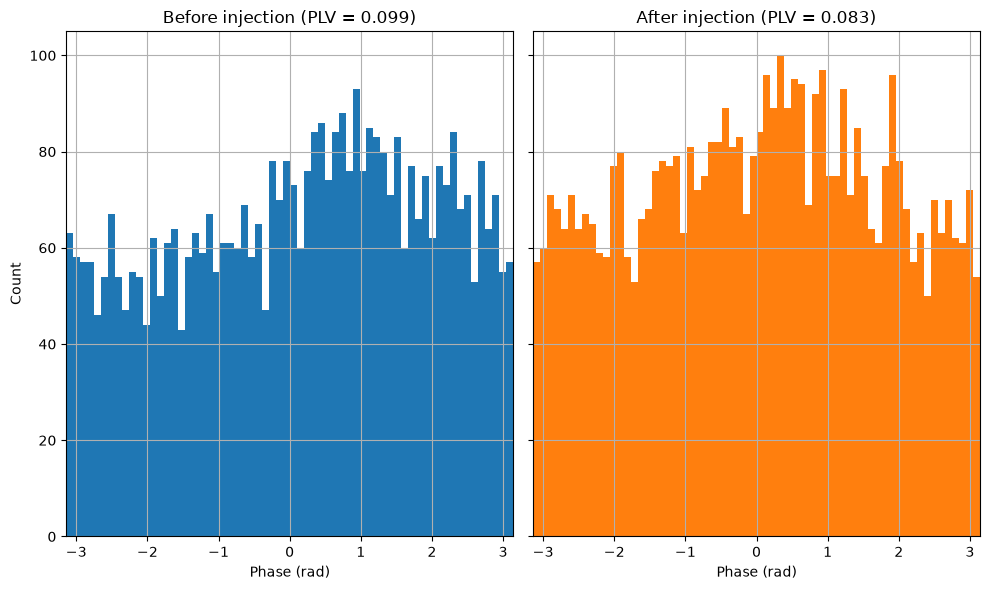

In [10]:
center_freq = 150.0 * pq.Hz
# center_freq = 75.0 * pq.Hz
# center_freq = 7.5 * pq.Hz

spike_times = spiketrain.times
spike_times_pre = spike_times[spike_times < 372 * pq.s]
plv_pre, phases_pre = compute_phase_locking_value(spike_times_pre, signal, center_freq, return_phase_values=True)
spike_times_post = spike_times[spike_times >= 372 * pq.s]
plv_post, phases_post = compute_phase_locking_value(spike_times_post, signal, center_freq, return_phase_values=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

ax = axes[0]
ax.set_title(f"Before injection (PLV = {plv_pre:.3f})")
ax.set_xlabel("Phase (rad)")
ax.set_ylabel("Count")
ax.hist(phases_pre, bins=64, range=(-np.pi, np.pi))
ax.set_xlim(-np.pi, np.pi)
ax.grid()

ax = axes[1]
ax.set_title(f"After injection (PLV = {plv_post:.3f})")
ax.set_xlabel("Phase (rad)")
ax.hist(phases_post, bins=64, range=(-np.pi, np.pi), color="C1")
ax.set_xlim(-np.pi, np.pi)
ax.grid()

fig.tight_layout()
plt.show()
